<a href="https://colab.research.google.com/github/tidocr0/TH-Deeplearning02/blob/main/THDLBuoi02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/500, Train Loss: 197350736.0000, Val Loss: 181408192.0000
Epoch 2/500, Train Loss: 196562560.0000, Val Loss: 180569968.0000
Epoch 3/500, Train Loss: 195777552.0000, Val Loss: 179735424.0000
Epoch 4/500, Train Loss: 194995680.0000, Val Loss: 178904496.0000
Epoch 5/500, Train Loss: 194216928.0000, Val Loss: 178077184.0000
Epoch 6/500, Train Loss: 193441296.0000, Val Loss: 177253520.0000
Epoch 7/500, Train Loss: 192668752.0000, Val Loss: 176433440.0000
Epoch 8/500, Train Loss: 191899296.0000, Val Loss: 175616960.0000
Epoch 9/500, Train Loss: 191132912.0000, Val Loss: 174804032.0000
Epoch 10/500, Train Loss: 190369600.0000, Val Loss: 173994656.0000
Epoch 11/500, Train Loss: 189609344.0000, Val Loss: 173188832.0000
Epoch 12/500, Train Loss: 188852096.0000, Val Loss: 172386544.0000
Epoch 13/500, Train Loss: 188097888.0000, Val Loss: 171587744.0000
Epoch 14/500, Train Loss: 187346720.0000, Val Loss: 170792432.0000
Epoch 15/500, Train Loss: 186598528.0000, Val Loss: 170000592.0000
Epoc

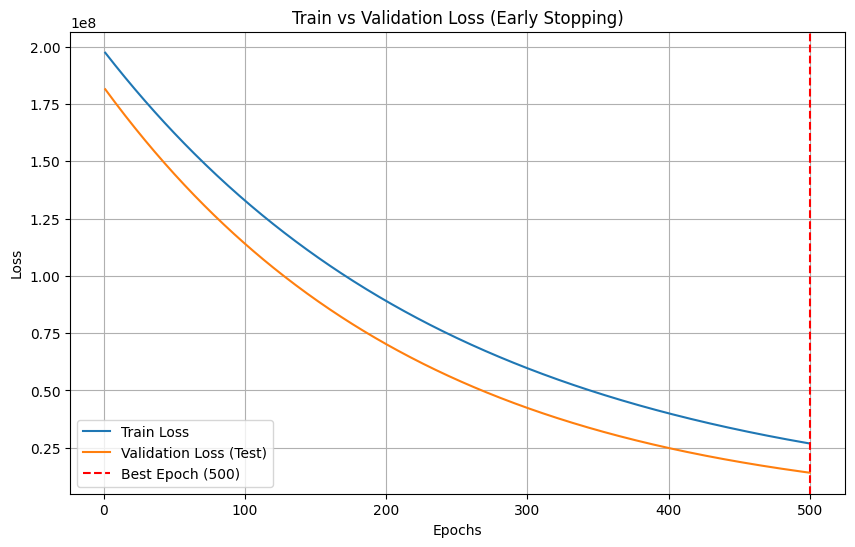

In [6]:
!pip install torch pandas scikit-learn matplotlib

import torch
import torch.nn as nn
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import copy
import matplotlib.pyplot as plt

data = pd.read_csv('carpricesdata.csv')
data = data.dropna()

target_col = 'Price'
X = data.drop(columns=[target_col])
y = data[target_col].values.reshape(-1, 1)

num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

if hasattr(X_train_scaled, "toarray"):
    X_train_scaled = X_train_scaled.toarray()
if hasattr(X_test_scaled, "toarray"):
    X_test_scaled = X_test_scaled.toarray()

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

input_dim = X_train_scaled.shape[1]
model = LinearRegressionModel(input_dim)

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

epochs = 500
patience = 10
best_loss = float('inf')
patience_counter = 0
best_model_weights = None
best_epoch = 0

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_predictions = model(X_test_tensor)
        val_loss = criterion(val_predictions, y_test_tensor).item()

    train_losses.append(loss.item())
    val_losses.append(val_loss)

    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}')

    if val_loss < best_loss:
        best_loss = val_loss
        patience_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        best_epoch = epoch + 1
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break

if best_model_weights is not None:
    model.load_state_dict(best_model_weights)

model.eval()
with torch.no_grad():
    final_predictions = model(X_test_tensor)
    final_loss = criterion(final_predictions, y_test_tensor)
    print(f'Final Testing Loss (Best Model from Epoch {best_epoch}): {final_loss.item():.4f}')

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss (Test)')
if best_epoch > 0:
    plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss (Early Stopping)')
plt.legend()
plt.grid(True)
plt.show()